In [8]:
import numpy as np
import matplotlib.pyplot as plt
import graph_style as gs
import fig_helper as fh

gs.set_graph_style(1)

def grad_Pij(x, e_L, e_R, e_corr):
    """
    Gradients of P00, P01, P10, P11 with respect to
    (e_L, e_R, e_corr).

    Returns
    -------
    grads : dict
        grads["P00"], etc. are arrays:
        [dP/de_L, dP/de_R, dP/de_corr]
    """

    # Decay parameters
    atr = 1 - 2*e_L - 2*e_R
    adt = 1 - 2*e_L - 2*e_R - 6*e_corr
    aL  = 1 - 2*e_L - 2*e_corr
    aR  = 1 - 2*e_R - 2*e_corr

    # Derivatives of S1 = aL^x
    dS1 = np.array([
        -2*x*aL**(x-1),   # e_L
        0,                 # e_R
        -2*x*aL**(x-1)    # e_corr
    ])

    # Derivatives of S2 = aR^x
    dS2 = np.array([
        0,
        -2*x*aR**(x-1),
        -2*x*aR**(x-1)
    ])

    # Derivatives of M1 = (2/3) adt^x
    dM1 = np.array([
        -(4*x/3)*adt**(x-1),
        -(4*x/3)*adt**(x-1),
        -4*x*adt**(x-1)
    ])

    # Derivatives of M2 = (1/3) atr^x
    dM2 = np.array([
        -(2*x/3)*atr**(x-1),
        -(2*x/3)*atr**(x-1),
        0
    ])

    # P00 = (1 + S1 + S2 + M1 + M2)/4
    grad_P00 = ( dS1 + dS2 + dM1 + dM2) / 4

    # P01 = (1 + S1 - S2 - M1 - M2)/4
    grad_P01 = ( dS1 - dS2 - dM1 - dM2) / 4

    # P10 = (1 - S1 + S2 - M1 - M2)/4
    grad_P10 = (-dS1 + dS2 - dM1 - dM2) / 4

    # P11 = (1 - S1 - S2 + M1 + M2)/4
    grad_P11 = (-dS1 - dS2 + dM1 + dM2) / 4

    return {
        "P00": grad_P00,
        "P01": grad_P01,
        "P10": grad_P10,
        "P11": grad_P11,
    }


def fisher_at_x(x, e_L, e_R, e_corr):
    # Compute probabilities here
    atr = 1 - 2*e_L - 2*e_R
    adt = 1 - 2*e_L - 2*e_R - 6*e_corr
    aL  = 1 - 2*e_L - 2*e_corr
    aR  = 1 - 2*e_R - 2*e_corr

    S1 = aL**x
    S2 = aR**x
    M1 = 2*adt**x / 3
    M2 = atr**x / 3

    probs = {
        "P00": (1 + S1 + S2 + M1 + M2) / 4,
        "P01": (1 + S1 - S2 - M1 - M2) / 4,
        "P10": (1 - S1 + S2 - M1 - M2) / 4,
        "P11": (1 - S1 - S2 + M1 + M2) / 4,
    }

    grads = grad_Pij(x, e_L, e_R, e_corr)

    I = np.zeros((3, 3))

    for key in probs:
        g = grads[key]
        I += np.outer(g, g) / probs[key]

    return I

def x2m(x_array):
    """ round each x to nearest integer > 1"""
    return np.array([max(2, int(round(x))) for x in x_array])

def fisher_for_array(x_array, e_L, e_R, e_corr, N):
    I_total = np.zeros((3, 3))

    m_array = x2m(x_array)
    for x in m_array:
        I_total += fisher_at_x(x, e_L, e_R, e_corr)
    return N*I_total

def cramer_rao_bound(x_array, e_L, e_R, e_corr, N):
    I_total = fisher_for_array(x_array, e_L, e_R, e_corr, N)
    return np.linalg.inv(I_total)


x_array = np.array([1, 2,4,8,16,32,64,128,256,512,1024])
N = 50*50
e_L = 0.001
e_R = 0.001
e_corr = 0.01
k = 1/e_L

I = fisher_for_array(x_array, e_L, e_R, e_corr, N)
print(f"Fisher information matrix at x={x_array}:\n{I}")

lamda_min = np.min(np.linalg.eigvals(I))/N
vec_min = np.linalg.eig(I)[1][:, np.argmin(np.linalg.eigvals(I))]
vec_min = vec_min / np.linalg.norm(vec_min)  # Normalize the eigenvector
print(f"Minimum eigenvalue of Fisher information matrix: {lamda_min}")
print(f"Eigenvector corresponding to minimum eigenvalue: {vec_min}")

det_I = np.linalg.det(I)/N**3
print(f"Determinant of Fisher information matrix: {det_I}")

cov = cramer_rao_bound(x_array, e_L, e_R, e_corr, N)
print(f"Cramer-Rao bound covariance matrix at x={x_array}:\n{cov}")

std_errors = np.sqrt(np.diag(cov))
print(f"Standard errors for e_L, e_R, e_corr: {std_errors}")

Fisher information matrix at x=[   1    2    4    8   16   32   64  128  256  512 1024]:
[[37718207.00381408 23184231.52415962 10087325.39759504]
 [23184231.52415962 37718207.00381408 10087325.39759504]
 [10087325.39759504 10087325.39759504 22479380.20937517]]
Minimum eigenvalue of Fisher information matrix: 5813.590191861788
Eigenvector corresponding to minimum eigenvalue: [ 7.07106781e-01 -7.07106781e-01  1.31541943e-15]
Determinant of Fisher information matrix: 1084156253810.7297
Cramer-Rao bound covariance matrix at x=[   1    2    4    8   16   32   64  128  256  512 1024]:
[[ 4.40454758e-08 -2.47588235e-08 -8.65463085e-09]
 [-2.47588235e-08  4.40454758e-08 -8.65463085e-09]
 [-8.65463085e-09 -8.65463085e-09  5.22525152e-08]]
Standard errors for e_L, e_R, e_corr: [0.00020987 0.00020987 0.00022859]


Decay parameter k: 226.77235979714106
Eigenvector at r=0.01: [-0.58 -0.58  0.58]
Eigenvector at r=0.10: [ 0.57  0.57 -0.59]
Eigenvector at r=1.05: [ 0.75 -0.64 -0.17]
Eigenvector at r=100.00: [ 0.72 -0.69 -0.08]


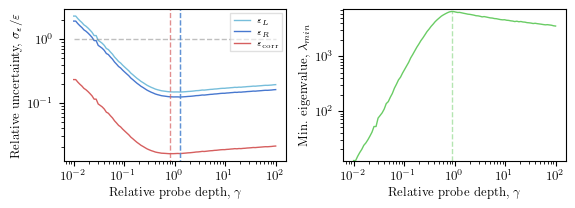

In [ ]:

N = 50*100
e_L = 0.001
e_R = 0.0012
e_corr = 0.01
k = -1/np.log(1-2*(e_L+e_R))
print(f"Decay parameter k: {k}")
trials = 100
r_arr = np.logspace(-2, 2, trials, base=10)  
stderr_e_L = np.array([])
stderr_e_R = np.array([])
stderr_e_corr = np.array([])
lambda_min_arr = np.array([])
det_arr = np.array([])
vec_min_arr = np.zeros((trials,3))  # Initialize an empty array to store eigenvectors
for i,r in enumerate(r_arr):
    x_max = r*k
    x_array = np.logspace(0, np.log(x_max), 10, base=np.e)  
    I = fisher_for_array(x_array, e_L, e_R, e_corr, N)
    lamda_min = np.min(np.linalg.eigvals(I))/N
    lambda_min_arr = np.append(lambda_min_arr, lamda_min)
    min_vec = np.linalg.eig(I)[1][:, np.argmin(np.linalg.eigvals(I))]
    min_vec = min_vec / np.linalg.norm(min_vec)  # Normalize the eigenvector
    vec_min_arr[i, :] = min_vec  # Store the eigenvector in the corresponding column

    det_I = np.linalg.det(I)/N**3
    det_arr = np.append(det_arr, det_I)


    cov = cramer_rao_bound(x_array, e_L, e_R, e_corr, N)

    std_errors = np.sqrt(np.diag(cov))

    stderr_e_L = np.append(stderr_e_L, std_errors[0])
    stderr_e_R = np.append(stderr_e_R, std_errors[1])
    stderr_e_corr = np.append(stderr_e_corr, std_errors[2])

fig_width = gs.get_fig_width()
fig_height = fig_width /2.7  # Adjust the height as needed
fig, axs = plt.subplots(1, 2, figsize=(fig_width, fig_height), sharex=True)

axs[0].plot(r_arr, stderr_e_L/e_L, label='$\\varepsilon_L$', color=gs.get_color(5), alpha=1.0, linestyle='solid')
axs[0].plot(r_arr, stderr_e_R/e_R, label='$\\varepsilon_R$', color=gs.get_color(6), alpha=1.0, linestyle='solid')
axs[0].plot(r_arr, stderr_e_corr/e_corr, label='$\\varepsilon_\\mathrm{corr}$', color=gs.get_color(2), alpha=1.0, linestyle='solid')
axs[0].hlines(1, r_arr[0], r_arr[-1], colors='gray', linestyles='dashed', alpha=0.5)
axs[0].set_ylabel('Relative uncertainty, $\\sigma_{\\varepsilon}/\\varepsilon$')
axs[0].legend()

axs[1].plot(r_arr, lambda_min_arr, label='lambda_min', color=gs.get_color(1), alpha=1.0, linestyle='solid')
axs[1].set_ylabel('Min. eigenvalue, $\\lambda_\\mathrm{min}$')
vec_0 =np.round(vec_min_arr[0], decimals=2)
vec_1 = np.round(vec_min_arr[-1], decimals=2)
vec_05 = np.round(vec_min_arr[trials//2], decimals=2)
vec_025 = np.round(vec_min_arr[trials//4], decimals=2)
print(f"Eigenvector at r={r_arr[0]:.2f}: {vec_0}")
print(f"Eigenvector at r={r_arr[trials//4]:.2f}: {vec_025}")
print(f"Eigenvector at r={r_arr[trials//2]:.2f}: {vec_05}")
print(f"Eigenvector at r={r_arr[-1]:.2f}: {vec_1}")

# axs[1].text(0.15, 0.25, f"Eigenvector at r={r_arr[0]:.2f}: {vec_0}", transform=axs[1].transAxes, fontsize=8, verticalalignment='top')
# axs[1].text(0.15, 0.20, f"Eigenvector at r={r_arr[trials//4]:.2f}:     {vec_025}", transform=axs[1].transAxes, fontsize=8, verticalalignment='top')
# axs[1].text(0.15, 0.15, f"Eigenvector at r={r_arr[trials//2]:.0f}:     {vec_05}", transform=axs[1].transAxes, fontsize=8, verticalalignment='top')
# axs[1].text(0.15, 0.10, f"Eigenvector at r={r_arr[-1]:.0f}:  {vec_1}", transform=axs[1].transAxes, fontsize=8, verticalalignment='top')


# axs[2].plot(r_arr, det_arr, label='determinant', color='purple', alpha=0.7)
# axs[2].set_ylabel('Det(I)')

for ax in axs:
    ax.set_yscale('log')
    ax.set_xscale('log')

def get_min_line(x,y):
    """ Get minimum x and y coord of each trace"""
    min_x = x[np.argmin(y)]
    min_y = np.min(y)
    return min_x, min_y

def get_max_line(x,y):
    """ Get maximum x and y coord of each trace"""
    max_x = x[np.argmax(y)]
    max_y = np.max(y)
    return max_x, max_y

min_e_corr, min_stderr_e_corr = get_min_line(r_arr, stderr_e_corr/e_corr)
min_e_L, min_stderr_e_L = get_min_line(r_arr, stderr_e_L/e_L)
min_e_R, min_stderr_e_R = get_min_line(r_arr, stderr_e_R/e_R)
max_lambda_min, max_lambda_val = get_max_line(r_arr, lambda_min_arr)
max_det, max_det_val = get_max_line(r_arr, det_arr)

axs[0].vlines(x=min_e_corr, ymin=1e-3, ymax=1e2, colors=gs.get_color(2), linestyles='dashed', alpha=0.7)
axs[0].vlines(x=min_e_L, ymin=1e-3, ymax=1e2, colors=gs.get_color(5), linestyles='dashed', alpha=0.7)
axs[0].vlines(x=min_e_R, ymin=1e-3, ymax=1e2, colors=gs.get_color(6), linestyles='dashed', alpha=0.7)
axs[1].vlines(x=max_lambda_min, ymin=np.min(lambda_min_arr), ymax=np.max(lambda_min_arr), colors=gs.get_color(1), linestyles='dashed', alpha=0.5)
# axs[2].vlines(x=max_det, ymin=np.min(det_arr), ymax=np.max(det_arr), colors='purple', linestyles='dashed', alpha=0.5)

axs[1].set_ylim(np.min(lambda_min_arr), np.max(lambda_min_arr)*1.1)
for ax in axs:
    # turn off grid
    ax.grid(False)
    ax.set_xlabel('Relative probe depth, $\\gamma$')
fig.tight_layout()
# axs[2].set_ylim(np.min(det_arr), np.max(det_arr)*1.1)

f_name = "..\\..\\pdf_figure\\ch4\\fisher_1.pdf"
fig.savefig(
    f_name,
)

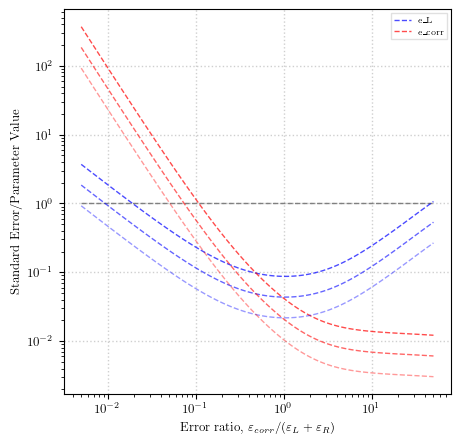

In [10]:

N = 50*100
e_L = 0.001
e_R = 0.001
e_corr_arr = np.logspace(np.log10(e_L)-2, np.log10(e_L)+2, 100, base=10)
e_r_arr = e_corr_arr/(e_L + e_R)
k = -1/np.log(1-2*(e_L+e_R))
x_array = np.logspace(0, np.log(k), 10, base=np.e)
def plot_fisher_errors(e_L, e_R, e_corr_arr, x_array, N):
    stderr_e_L = np.array([])
    stderr_e_R = np.array([])
    stderr_e_corr = np.array([])
    cov_corr_L = np.array([])
    for j, e_corr in enumerate(e_corr_arr):
        I = fisher_for_array(x_array, e_L, e_R, e_corr, N)
        # lamda_min = np.min(np.linalg.eigvals(I))/N

        cov = cramer_rao_bound(x_array, e_L, e_R, e_corr, N)
        cov_corr_L = np.append(cov_corr_L, cov[0, 2])

        std_errors = np.sqrt(np.diag(cov))
        stderr_e_L = np.append(stderr_e_L, std_errors[0])
        stderr_e_R = np.append(stderr_e_R, std_errors[1])
        stderr_e_corr = np.append(stderr_e_corr, std_errors[2])
    return stderr_e_L, stderr_e_R, stderr_e_corr, cov_corr_L


fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.hlines(y=1, xmin=e_r_arr[0], xmax=e_r_arr[-1], colors='gray', linestyles='dashed')

stderr_e_L, stderr_e_R, stderr_e_corr, cov_corr_L = plot_fisher_errors(e_L, e_R, e_corr_arr, x_array, 50*100)
ax.plot(e_r_arr, stderr_e_L/e_L, label='e_L', color='blue', alpha=0.7)
# ax.plot(e_r_arr, stderr_e_R/e_R, label='e_R', color='lightblue', alpha=0.7)
ax.plot(e_r_arr, stderr_e_corr/e_corr_arr, label='e_corr', color='red', alpha=0.7)

stderr_e_L, stderr_e_R, stderr_e_corr, cov_corr_L = plot_fisher_errors(e_L, e_R, e_corr_arr, x_array, 50*100*4)
ax.plot(e_r_arr, stderr_e_L/e_L, color='blue', alpha=0.6, linestyle='dashed')
# ax.plot(e_r_arr, stderr_e_R/e_R, color='lightblue', alpha=0.6, linestyle='dashed')
ax.plot(e_r_arr, stderr_e_corr/e_corr_arr, color='red', alpha=0.6, linestyle='dashed')

stderr_e_L, stderr_e_R, stderr_e_corr, cov_corr_L = plot_fisher_errors(e_L, e_R, e_corr_arr, x_array, 50*100*4*4)
ax.plot(e_r_arr, stderr_e_L/e_L, color='blue', alpha=0.4, linestyle='dashed')
# ax.plot(e_r_arr, stderr_e_R/e_R, color='lightblue', alpha=0.4, linestyle='dashed')
ax.plot(e_r_arr, stderr_e_corr/e_corr_arr, color='red', alpha=0.4, linestyle='dashed')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Error ratio, $\\varepsilon_{corr}/(\\varepsilon_{L}+\\varepsilon_{R})$')
ax.set_ylabel('Standard Error/Parameter Value')
ax.legend()


In [11]:
# Now include parity measurements
def grad_Parij(x, e_L, e_R, e_corr):
    """
    Gradients of parity P00, P01, P10, P11 with respect to
    (e_L, e_R, e_corr).

    Returns
    -------
    grads : dict
        grads["P00"], etc. are arrays:
        [dP/de_L, dP/de_R, dP/de_corr]
    """

    # Decay parameters
    atr = 1 - 2*e_L - 2*e_R
    adt = 1 - 2*e_L - 2*e_R - 6*e_corr

    # Derivatives of A1 = (1/3)atr^x
    dA1 = np.array([
        -(2*x/3)*atr**(x-1),
        -(2*x/3)*atr**(x-1),
        0
    ])

    # Derivatives of A2 = (2/3) adt^x
    dA2 = np.array([
        -(4*x/3)*adt**(x-1),
        -(4*x/3)*adt**(x-1),
        -4*x*adt**(x-1)
    ])


    # Par00 = (1 + A1 - A2)/4
    grad_P00 = ( dA1 - dA2) / 4
    # Par01 = (1 - A1 + A2)/4
    grad_P01 = (-dA1 + dA2) / 4
    # Par10 = (1 - A1 + A2)/4
    grad_P10 = (-dA1 + dA2) / 4
    # Par11 = (1 + A1 - A2)/4
    grad_P11 = ( dA1 - dA2) / 4

    return {
        "Par00": grad_P00,
        "Par01": grad_P01,
        "Par10": grad_P10,
        "Par11": grad_P11,
    }


def par_fisher_at_x(x, e_L, e_R, e_corr):
    # Compute probabilities here
    atr = 1 - 2*e_L - 2*e_R
    adt = 1 - 2*e_L - 2*e_R - 6*e_corr

    A1 = atr**x / 3
    A2 = adt**x / 3

    probs = {
        "Par00": (1 +  A1 - A2) / 4,
        "Par01": (1 -  A1 + A2) / 4,
        "Par10": (1 -  A1 + A2) / 4,
        "Par11": (1 +  A1 - A2) / 4,
    }

    grads = grad_Parij(x, e_L, e_R, e_corr)

    I = np.zeros((3, 3))

    for key in probs:
        g = grads[key]
        I += np.outer(g, g) / probs[key]

    return I

def par_fisher_for_array(x_array, e_L, e_R, e_corr, N):
    """ Half the shots for Z exp, half for Parity exp"""
    I_total = np.zeros((3, 3))
    ratio = 0.5  # Ratio of shots for parity measurements
    m_array = x2m(x_array)
    for x in m_array:
        I_total += ratio * par_fisher_at_x(x, e_L, e_R, e_corr)
        I_total += (1-ratio) * fisher_at_x(x, e_L, e_R, e_corr)
    return N*I_total

def par_cramer_rao_bound(x_array, e_L, e_R, e_corr, N):
    I_total = par_fisher_for_array(x_array, e_L, e_R, e_corr, N)
    return np.linalg.inv(I_total)



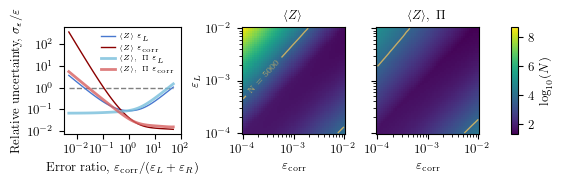

In [12]:
N = 50*100
e_L = 0.001
e_R = 0.001
e_corr_arr = np.logspace(np.log10(e_L)-2, np.log10(e_L)+2, 100, base=10)
e_r_arr = e_corr_arr/(e_L + e_R)
k = -1/np.log(1-2*(e_L+e_R))
x_array = np.logspace(0, np.log(k), 10, base=np.e)
def plot_par_fisher_errors(e_L, e_R, e_corr_arr, x_array, N):
    stderr_e_L = np.array([])
    stderr_e_R = np.array([])
    stderr_e_corr = np.array([])
    cov_corr_L = np.array([])
    for j, e_corr in enumerate(e_corr_arr):
        I = par_fisher_for_array(x_array, e_L, e_R, e_corr, N)
        # lamda_min = np.min(np.linalg.eigvals(I))/N

        cov = par_cramer_rao_bound(x_array, e_L, e_R, e_corr, N)
        cov_corr_L = np.append(cov_corr_L, cov[0, 2])

        std_errors = np.sqrt(np.diag(cov))
        stderr_e_L = np.append(stderr_e_L, std_errors[0])
        stderr_e_R = np.append(stderr_e_R, std_errors[1])
        stderr_e_corr = np.append(stderr_e_corr, std_errors[2])
    return stderr_e_L, stderr_e_R, stderr_e_corr, cov_corr_L

fig_width = gs.get_fig_width()
fig_height = fig_width / 3.7  # Adjust the height as needed
fig, axs = plt.subplots(
    1, 4,
    width_ratios=[1, 0.7, 0.7, 0.05],
    figsize=(fig_width, fig_height)
)

# Make b and c share y-axis
axs[2].sharey(axs[1])
axs[2].tick_params(labelleft=False)


cax = axs[3]  # Colorbar axis

# fig = plt.figure(figsize=(fig_width, fig_height))

# # Main layout: left plot + heatmap region
# grids = fig.add_gridspec(
#     1, 2,
#     width_ratios=[1, 2.5],
#     wspace=0.30
# )

# ax0 = fig.add_subplot(grids[0])

# # Tightly packed heatmaps + colorbar
# gs_right = grids[1].subgridspec(
#     1, 3,
#     width_ratios=[1, 1, 0.045],
#     wspace=0.28
# )

# ax1 = fig.add_subplot(gs_right[0])
# ax2 = fig.add_subplot(gs_right[1], sharey=ax1)
# cax = fig.add_subplot(gs_right[2])
# axs = [ax0, ax1, ax2]

ax = axs[0]
ax.hlines(y=1, xmin=e_r_arr[0], xmax=e_r_arr[-1], colors='gray', linestyles='dashed')


stderr_e_L, stderr_e_R, stderr_e_corr, cov_corr_L = plot_fisher_errors(e_L, e_R, e_corr_arr, x_array, N)
ax.plot(e_r_arr, stderr_e_L/e_L, label='$\\langle Z\\rangle~\\varepsilon_L$', color=gs.get_color(6), alpha=1.0, linestyle='solid')
# ax.plot(e_r_arr, stderr_e_R/e_R, label='e_R', color='lightblue', alpha=0.7)
ax.plot(e_r_arr, stderr_e_corr/e_corr_arr, label='$\\langle Z\\rangle~\\varepsilon_\\mathrm{corr}$', color='darkred', alpha=1.0, linestyle='solid')

stderr_e_L, stderr_e_R, stderr_e_corr, cov_corr_L = plot_par_fisher_errors(e_L, e_R, e_corr_arr, x_array, N)
ax.plot(e_r_arr, stderr_e_L/e_L, label='$\\langle Z \\rangle,~\\Pi~\\varepsilon_L$', color=gs.get_color(5), alpha=0.8, linestyle='solid', linewidth=2)
# ax.plot(e_r_arr, stderr_e_R/e_R, label='e_R', color='lightblue', alpha=0.7)
ax.plot(e_r_arr, stderr_e_corr/e_corr_arr, label='$\\langle Z\\rangle,~\\Pi~\\varepsilon_\\mathrm{corr}$', color=gs.get_color(2), alpha=0.8, linestyle='solid', linewidth=2)

# stderr_e_L, stderr_e_R, stderr_e_corr, cov_corr_L = plot_par_fisher_errors(e_L, e_R, e_corr_arr, x_array, N*4)
# ax.plot(e_r_arr, stderr_e_L/e_L, color='blue', alpha=0.6, linestyle='dashed')
# # ax.plot(e_r_arr, stderr_e_R/e_R, color='lightblue', alpha=0.6, linestyle='dashed')
# ax.plot(e_r_arr, stderr_e_corr/e_corr_arr, color='red', alpha=0.6, linestyle='dashed')

# stderr_e_L, stderr_e_R, stderr_e_corr, cov_corr_L = plot_par_fisher_errors(e_L, e_R, e_corr_arr, x_array, N*4**2)
# ax.plot(e_r_arr, stderr_e_L/e_L, color='blue', alpha=0.4, linestyle='dashed')
# # ax.plot(e_r_arr, stderr_e_R/e_R, color='lightblue', alpha=0.4, linestyle='dashed')
# ax.plot(e_r_arr, stderr_e_corr/e_corr_arr, color='red', alpha=0.4, linestyle='dashed')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Error ratio, $\\varepsilon_\\mathrm{corr}/(\\varepsilon_{L}+\\varepsilon_{R})$')
ax.set_ylabel('Relative uncertainty, $\\sigma_{\\varepsilon}/\\varepsilon$')
ax.grid(False)
ax.set_xticks([1e-2, 1e-1, 1, 10, 100])
ax.set_yticks([1e-2, 1e-1, 1, 10, 100])
ax.legend(fontsize=5, loc='upper right', frameon=False, ncol=1)
# Parameter space
n_grid = 50

e_L_arr = np.logspace(-4, -2, n_grid)
e_corr_arr = np.logspace(-4, -2, n_grid)

Z = np.full((n_grid, n_grid), np.nan)
Z_Par = np.full((n_grid, n_grid), np.nan)
N_required_L = np.full((n_grid, n_grid), np.nan)
N_required_corr = np.full((n_grid, n_grid), np.nan)

for j, e_L in enumerate(e_L_arr):
    for i, e_corr in enumerate(e_corr_arr):

        # Constraint
        e_R = e_L

        # Slow decay:
        # atr = 1 - 2(e_L + e_R)
        k = -1/np.log(1-2*(e_L+e_R))

        # Log-spaced m probes from 1 to m_max
        x_array = np.logspace(0, np.log(k), 10, base=np.e)

        # Fisher information for N=1 shot at each m
        I1 = fisher_for_array(
            x_array,
            e_L,
            e_R,
            e_corr,
            N=1
        )

        I2 = par_fisher_for_array(
            x_array,
            e_L,
            e_R,
            e_corr,
            N=1
        )

        try:
            cov1 = np.linalg.inv(I1)
        except np.linalg.LinAlgError:
            continue

        try:
            cov2 = np.linalg.inv(I2)
        except np.linalg.LinAlgError:
            continue

        # Required shots per m to achieve
        # sigma(e_i) <= e_i
        N_L = cov1[0, 0] / e_L**2
        N_corr = cov1[2, 2] / e_corr**2

        N_required_L[j, i] = N_L
        N_required_corr[j, i] = N_corr

        # Must satisfy both requirements
        Z[j, i] = max(N_L, N_corr)

        # Required shots per m to achieve
        # sigma(e_i) <= e_i
        N_L = cov2[0, 0] / e_L**2
        N_corr = cov2[2, 2] / e_corr**2

        N_required_L[j, i] = N_L
        N_required_corr[j, i] = N_corr

        # Must satisfy both requirements
        Z_Par[j, i] = max(N_L, N_corr)


vmin = np.log10(min(np.nanmin(Z), np.nanmin(Z_Par)))
vmax = np.log10(max(np.nanmax(Z), np.nanmax(Z_Par)))

im1 = axs[1].pcolormesh(
    e_corr_arr,
    e_L_arr,
    np.log10(Z),
    shading="auto",
    vmin=vmin,
    vmax=vmax,
    rasterized=True
)
im2 = axs[2].pcolormesh(
    e_corr_arr,
    e_L_arr,
    np.log10(Z_Par),
    shading="auto",
    vmin=vmin,
    vmax=vmax,
    rasterized=True
)

axs[1].set_ylabel("$\\varepsilon_L$")
cbar = fig.colorbar(im1, cax=cax)
cbar.set_label(r"$\log_{10}(N)$")
for ax, im in zip([axs[1], axs[2]], [im1, im2]):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("$\\varepsilon_\\mathrm{corr}$")
    ax.grid(False)



axs[1].set_title(
    "$\\langle Z\\rangle$"
)

axs[2].set_title(
    "$\\langle Z\\rangle,~\\Pi$"
)

levels = [5e3]

CS1 = axs[1].contour(
    e_L_arr,
    e_corr_arr,
    Z,
    levels=levels,
    colors=gs.get_color(4),
    linewidths=1
)
CS2 = axs[2].contour(
    e_L_arr,
    e_corr_arr,
    Z_Par,
    levels=levels,
    colors=gs.get_color(4),
    linewidths=1
)

fig.subplots_adjust(
    left=0.10,
    right=0.88,
    bottom=0.20,
    top=0.88,
    wspace=0.35,   # increase this
)

pos = axs[0].get_position()

axs[0].set_position([
    pos.x0,
    pos.y0,
    pos.width * 0.8,
    pos.height
])

axs[1].clabel(CS1, fmt={5000: "N = 5000"}, inline=True, fontsize=6)
axs[1].sharey(axs[2]) 
axs[2].tick_params(labelleft=False)
axs[2].set_ylabel("")
cax.grid(False)
f_name = "..\\..\\pdf_figure\\ch4\\fisher_2.pdf"
fig.savefig(
    f_name,
    bbox_inches="tight",
    pad_inches=0.1
)

Decay parameter k: 249.49966599830609


(np.float64(124625639.97492996), np.float64(401048570742.86304))

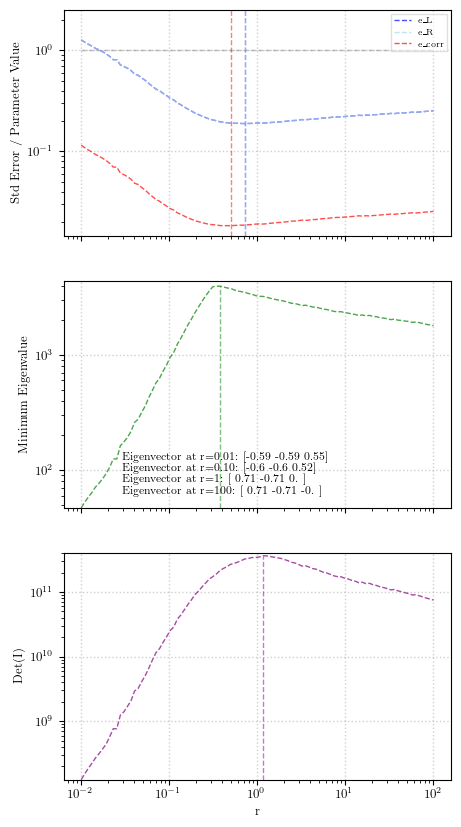

In [13]:

N = 50*100
e_L = 0.001
e_R = 0.001
e_corr = 0.01
k = -1/np.log(1-2*(e_L+e_R))
print(f"Decay parameter k: {k}")
trials = 100
r_arr = np.logspace(-2, 2, trials, base=10)  
stderr_e_L = np.array([])
stderr_e_R = np.array([])
stderr_e_corr = np.array([])
lambda_min_arr = np.array([])
det_arr = np.array([])
vec_min_arr = np.zeros((trials,3))  # Initialize an empty array to store eigenvectors
for i,r in enumerate(r_arr):
    x_max = r*k
    x_array = np.logspace(0, np.log(x_max), 10, base=np.e)  
    I = par_fisher_for_array(x_array, e_L, e_R, e_corr, N)
    lamda_min = np.min(np.linalg.eigvals(I))/N
    lambda_min_arr = np.append(lambda_min_arr, lamda_min)
    min_vec = np.linalg.eig(I)[1][:, np.argmin(np.linalg.eigvals(I))]
    min_vec = min_vec / np.linalg.norm(min_vec)  # Normalize the eigenvector
    vec_min_arr[i, :] = min_vec  # Store the eigenvector in the corresponding column

    det_I = np.linalg.det(I)/N**3
    det_arr = np.append(det_arr, det_I)


    cov = par_cramer_rao_bound(x_array, e_L, e_R, e_corr, N)

    std_errors = np.sqrt(np.diag(cov))

    stderr_e_L = np.append(stderr_e_L, std_errors[0])
    stderr_e_R = np.append(stderr_e_R, std_errors[1])
    stderr_e_corr = np.append(stderr_e_corr, std_errors[2])

fig, axs = plt.subplots(3, 1, figsize=(5, 10), sharex=True)

axs[0].plot(r_arr, stderr_e_L/e_L, label='e_L', color='blue', alpha=0.7)
axs[0].plot(r_arr, stderr_e_R/e_R, label='e_R', color='lightblue', alpha=0.7)
axs[0].plot(r_arr, stderr_e_corr/e_corr, label='e_corr', color='red', alpha=0.7)
axs[0].hlines(1, r_arr[0], r_arr[-1], colors='gray', linestyles='dashed', alpha=0.5)
axs[0].set_ylabel('Std Error / Parameter Value')
axs[0].legend()

axs[1].plot(r_arr, lambda_min_arr, label='lambda_min', color='green', alpha=0.7)
axs[1].set_ylabel('Minimum Eigenvalue')
vec_0 =np.round(vec_min_arr[0], decimals=2)
vec_1 = np.round(vec_min_arr[-1], decimals=2)
vec_05 = np.round(vec_min_arr[trials//2], decimals=2)
vec_025 = np.round(vec_min_arr[trials//4], decimals=2)
axs[1].text(0.15, 0.25, f"Eigenvector at r={r_arr[0]:.2f}: {vec_0}", transform=axs[1].transAxes, fontsize=8, verticalalignment='top')
axs[1].text(0.15, 0.20, f"Eigenvector at r={r_arr[trials//4]:.2f}:     {vec_025}", transform=axs[1].transAxes, fontsize=8, verticalalignment='top')
axs[1].text(0.15, 0.15, f"Eigenvector at r={r_arr[trials//2]:.0f}:     {vec_05}", transform=axs[1].transAxes, fontsize=8, verticalalignment='top')
axs[1].text(0.15, 0.10, f"Eigenvector at r={r_arr[-1]:.0f}:  {vec_1}", transform=axs[1].transAxes, fontsize=8, verticalalignment='top')


axs[2].plot(r_arr, det_arr, label='determinant', color='purple', alpha=0.7)
axs[2].set_ylabel('Det(I)')
axs[2].set_xlabel('r')

for ax in axs:
    ax.set_yscale('log')
    ax.set_xscale('log')

def get_min_line(x,y):
    """ Get minimum x and y coord of each trace"""
    min_x = x[np.argmin(y)]
    min_y = np.min(y)
    return min_x, min_y

def get_max_line(x,y):
    """ Get maximum x and y coord of each trace"""
    max_x = x[np.argmax(y)]
    max_y = np.max(y)
    return max_x, max_y

min_e_corr, min_stderr_e_corr = get_min_line(r_arr, stderr_e_corr/e_corr)
min_e_L, min_stderr_e_L = get_min_line(r_arr, stderr_e_L/e_L)
min_e_R, min_stderr_e_R = get_min_line(r_arr, stderr_e_R/e_R)
max_lambda_min, max_lambda_val = get_max_line(r_arr, lambda_min_arr)
max_det, max_det_val = get_max_line(r_arr, det_arr)

axs[0].vlines(x=min_e_corr, ymin=1e-3, ymax=1e2, colors='red', linestyles='dashed', alpha=0.5)
axs[0].vlines(x=min_e_L, ymin=1e-3, ymax=1e2, colors='blue', linestyles='dashed', alpha=0.5)
axs[0].vlines(x=min_e_R, ymin=1e-3, ymax=1e2, colors='lightblue', linestyles='dashed', alpha=0.5)
axs[1].vlines(x=max_lambda_min, ymin=np.min(lambda_min_arr), ymax=np.max(lambda_min_arr), colors='green', linestyles='dashed', alpha=0.5)
axs[2].vlines(x=max_det, ymin=np.min(det_arr), ymax=np.max(det_arr), colors='purple', linestyles='dashed', alpha=0.5)

axs[1].set_ylim(np.min(lambda_min_arr), np.max(lambda_min_arr)*1.1)
axs[2].set_ylim(np.min(det_arr), np.max(det_arr)*1.1)